In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from functools import partial
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
from scipy.optimize import differential_evolution, least_squares
from matplotlib.patches import ConnectionPatch

In [2]:
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

def double_cloud(lam,SL,SU,tau0L,tau0U,vL,vU,WL,WU,I0):
    lam0=6562.8
    c=299790
    tauL=tau0L*np.exp(-((lam-lam0-vL*lam0/c)**2)/WL**2)
    tauU=tau0U*np.exp(-((lam-lam0-vU*lam0/c)**2)/WU**2)
    I=I0*np.exp(-(tauL+tauU))+SL*(1-np.exp(-tauL))*np.exp(-tauU)+SU*(1-np.exp(-tauU))
    return I

In [4]:
#数据准备
dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=44
right_index=96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam00[left_index:right_index]#±1.5A
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
print(lam00[39],lam00[44],lam00[54],lam00[96],lam00[101])

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735


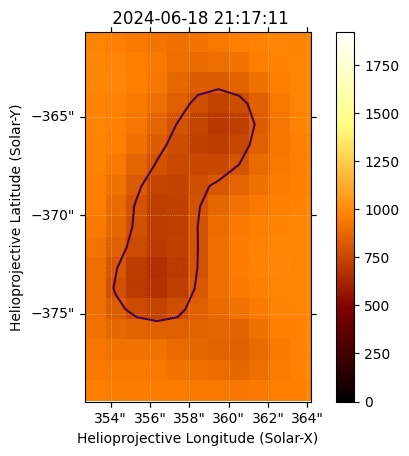

In [7]:
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)

fig=plt.figure()
jet_point4=(1515,789)
point4=hawing_map.wcs.pixel_to_world(jet_point4[0],jet_point4[1])
jet_point5=(1525,806)
point5=hawing_map.wcs.pixel_to_world(jet_point5[0],jet_point5[1])
jet_region=sub_hawing_map.submap(point4,top_right=point5)
ax3=fig.add_subplot(projection=jet_region)
im=jet_region.plot(axes=ax3,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
cbar=fig.colorbar(im,ax=ax3)
contour=ax3.contour(jet_region.data,levels=[800],transform=ax3.get_transform(jet_region.wcs))

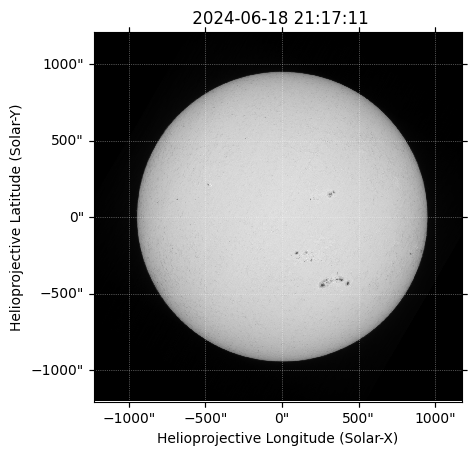

In [8]:
hawing_map.plot()

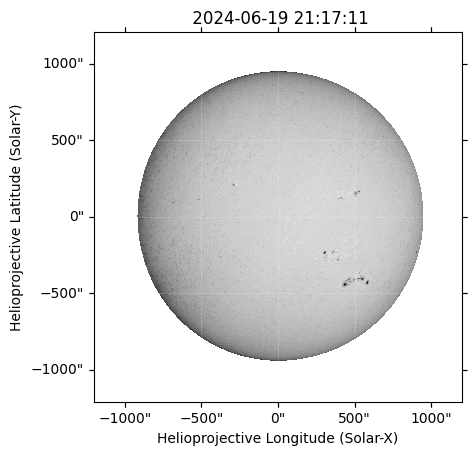

In [9]:
out_time=hawing_map.date+1*u.day
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
out_frame=Helioprojective(observer='earth',obstime=out_time,rsun=hawing_map.coordinate_frame.rsun)
aiamap=hawing_map
out_center = SkyCoord(0*u.arcsec, 0*u.arcsec, frame=out_frame)
header = sunpy.map.make_fitswcs_header(aiamap.data.shape,
                                       out_center,
                                       scale=u.Quantity(aiamap.scale))
from astropy.wcs import WCS
out_wcs = WCS(header)
with propagate_with_solar_surface():
    out_warp = aiamap.reproject_to(out_wcs)
fig = plt.figure()
ax = fig.add_subplot(projection=out_warp)
out_warp.plot(axes=ax)

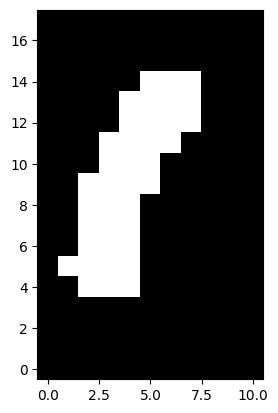

In [10]:
#由contour生成mask
cs = contour
from matplotlib.path import Path
# 初始化 mask
mask = np.zeros_like(jet_region.data, dtype=bool)

# 构造像素坐标网格
ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T  # (N, 2)

# 遍历所有封闭区域
for path in cs.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)
# 现在 mask 就是一个布尔数组，True 表示在等值线包围区域内
plt.figure()
plt.imshow(mask, origin='lower', cmap='gray')
#plt.title("等值线区域 mask")
plt.show()

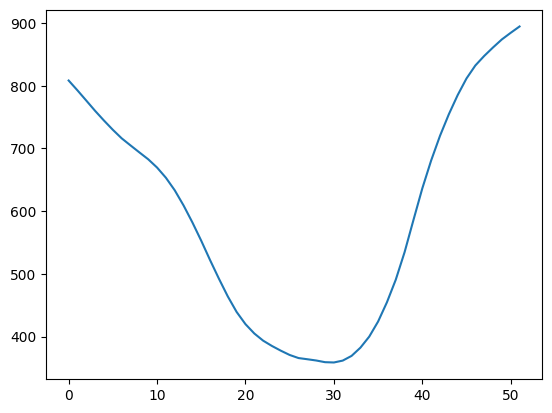

In [11]:
#把mask应用到数据上，得到目标区域的平均光谱曲线
data_jet=rsm[1].data[left_index:right_index,789:807,1515:1526]
data_mask=np.tile(~mask,(right_index-left_index,1,1))
jet_masked=np.ma.array(data_jet,mask=data_mask)
spec_data=jet_masked.mean(axis=(1,2))
plt.plot(spec_data)

In [12]:
array_spec_data=np.array(spec_data)
print(array_spec_data)

[808.36842105 792.60526316 776.28947368 759.86842105 744.44736842
 729.73684211 716.13157895 704.84210526 693.71052632 682.73684211
 669.55263158 653.28947368 633.26315789 609.05263158 581.94736842
 552.71052632 521.81578947 492.18421053 464.02631579 439.21052632
 419.76315789 404.86842105 393.42105263 384.92105263 377.42105263
 370.60526316 365.68421053 363.78947368 361.78947368 359.10526316
 358.63157895 361.63157895 369.13157895 382.23684211 399.89473684
 423.92105263 454.63157895 490.68421053 534.71052632 585.89473684
 636.23684211 680.76315789 720.07894737 754.47368421 785.07894737
 811.65789474 832.34210526 847.52631579 861.10526316 873.92105263
 884.47368421 894.55263158]


In [13]:
print(spec_data)

[808.3684210526316 792.6052631578947 776.2894736842105 759.8684210526316
 744.4473684210526 729.7368421052631 716.1315789473684 704.8421052631579
 693.7105263157895 682.7368421052631 669.5526315789474 653.2894736842105
 633.2631578947369 609.0526315789474 581.9473684210526 552.7105263157895
 521.8157894736842 492.1842105263158 464.0263157894737 439.2105263157895
 419.7631578947368 404.86842105263156 393.42105263157896
 384.92105263157896 377.42105263157896 370.60526315789474
 365.6842105263158 363.7894736842105 361.7894736842105 359.10526315789474
 358.63157894736844 361.63157894736844 369.13157894736844
 382.2368421052632 399.89473684210526 423.92105263157896
 454.63157894736844 490.6842105263158 534.7105263157895 585.8947368421053
 636.2368421052631 680.7631578947369 720.078947368421 754.4736842105264
 785.078947368421 811.6578947368421 832.3421052631579 847.5263157894736
 861.1052631578947 873.921052631579 884.4736842105264 894.5526315789474]


In [14]:
np.load('x_opt.npy')

array([-1.59254773e+00, -1.77863210e-01,  2.07825975e+01, -1.56526149e+01,
        2.28858429e+00,  4.00639111e+00,  1.51931132e+02,  4.40857490e+02])

In [15]:
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
print(I0)

[1028.08799049 1019.84661118 1011.11296076 1001.58858502  991.49227111
  980.66825208  968.82401902  956.02378121  942.26872771  926.80499405
  907.84066587  883.75386445  852.74554102  812.73602854  761.65636147
  699.99524376  632.33174792  563.882283    498.42925089  440.02259215
  392.18073722  355.156956    328.00237812  308.85612366  295.68965517
  286.63852556  280.79191439  278.16171225  278.64209275  282.46135553
  292.15814507  308.96195006  332.88347206  365.24494649  409.21997622
  464.55648038  526.89060642  592.24256837  656.99048751  716.99762188
  769.95600476  813.95362663  850.29369798  880.42568371  904.72175981
  924.13555291  939.35790725  952.17360285  963.04399524  973.06777646
  982.10107015  990.92033294]


In [16]:
lam=lam00[left_index:right_index]#±1.5A
lam0=6562.8
c_km=299792.458
vel = (lam - lam0) / lam0 * c_km
print(vel)

[-57.19122539 -54.97644656 -52.76166773 -50.54688889 -48.33211006
 -46.11733123 -43.90255239 -41.68777356 -39.47299472 -37.25821589
 -35.04343706 -32.82865822 -30.61387939 -28.39910056 -26.18432172
 -23.96954289 -21.75476405 -19.53998522 -17.32520639 -15.11042755
 -12.89564872 -10.68086989  -8.46609105  -6.25131222  -4.03653338
  -1.82175455   0.39302428   2.60780312   4.82258195   7.03736078
   9.25213962  11.46691845  13.68169729  15.89647612  18.11125495
  20.32603379  22.54081262  24.75559145  26.97037029  29.18514912
  31.39992796  33.61470679  35.82948562  38.04426446  40.25904329
  42.47382213  44.68860096  46.90337979  49.11815863  51.33293746
  53.54771629  55.76249513]


In [17]:
I_I0_vel=np.zeros((3,52))
I_I0_vel[0,:]=array_spec_data
I_I0_vel[1,:]=I0
I_I0_vel[2,:]=vel
np.save('I_I0_vel.npy',I_I0_vel)

DE finished, SSE: 2906.8266447785227
SL=5917.449, SU=394.425
tau0L=0.0589, tau0U=1.3853
vL=-29.774 km/s, vU=-12.277 km/s
WL=16.1840 km/s, WU=41.9331 km/s
拟合误差: 4296.26726194404


Text(0.5, 0, 'Wavelength (Angstrom)')

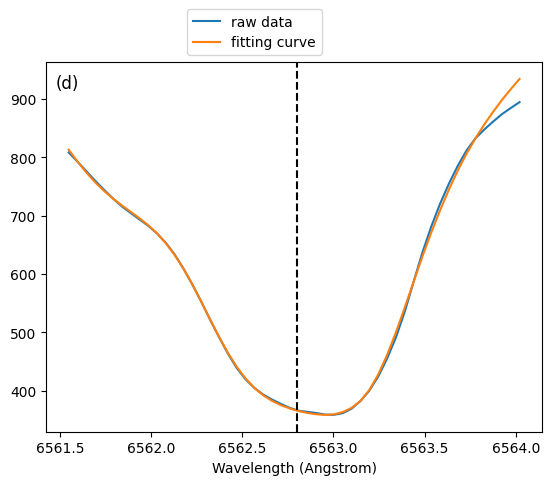

In [18]:
import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)
# 1. wavelength → velocity
lam=lam00[left_index:right_index]#±1.5A
vel = (lam - lam0) / lam0 * c_km  # km/s
I=spec_data
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
# ===== 固定的背景连续谱强度 =====
Icont = I0  # 你之前定义的背景值，例如在平静区域测得的平均值

# 2. 双云模型（去掉 Icont 作为拟合变量）
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

# 3. 残差函数
def residuals(params, vel, I, Icont):
    return double_cloud_vel(params, vel, Icont) - I

# 4. 参数范围
# log tau: [1e-3, 1e2]
# W: [0.05, 200] km/s
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -200.0, -200.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0                       # SL, SU
]
ub = [
    np.log(1e2), np.log(1e2),
    200.0, 200.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10
]
bounds = list(zip(lb, ub))

# 5. DE全局搜索
def ssq_obj(x):
    res = residuals(x, vel, I, Icont)
    return np.sum(res**2)

result_de = differential_evolution(ssq_obj, bounds, maxiter=800, popsize=15, tol=1e-6)
x_de = result_de.x
print("DE finished, SSE:", result_de.fun)

# 6. 局部精炼
lsq = least_squares(residuals, x_de, args=(vel, I, Icont),
                    bounds=(np.array(lb), np.array(ub)),
                    loss='soft_l1', f_scale=0.1,
                    x_scale='jac', max_nfev=2000)
x_opt = lsq.x

# 7. 拆解结果
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = x_opt
tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
WL = np.exp(lWl); WU = np.exp(lWu)


print(f"SL={SL:.3f}, SU={SU:.3f}")
print(f"tau0L={tau0L:.4f}, tau0U={tau0U:.4f}")
print(f"vL={vL:.3f} km/s, vU={vU:.3f} km/s")
print(f"WL={WL:.4f} km/s, WU={WU:.4f} km/s")

# 8. 作图
y_fit = double_cloud_vel(x_opt, vel, Icont)
print('拟合误差:',np.sum((I-y_fit)**2))
fig,ax=plt.subplots()
ax.plot(lam, I, label='raw data')
ax.plot(lam, y_fit, label='fitting curve')
ax.text(0.02,0.93,'(d)',color='black',transform=ax.transAxes,fontsize=12)
ax.axvline(lam0, linestyle='--',color='black')
ax.legend(bbox_to_anchor=(0.27, 1))
ax.set_xlabel('Wavelength (Angstrom)')

In [19]:
np.save('x_opt.npy',x_opt)

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\xiao\AppData\Local\Temp\ipykernel_15420\3759353382.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Wavelength $(\mathrm{\AA})$')


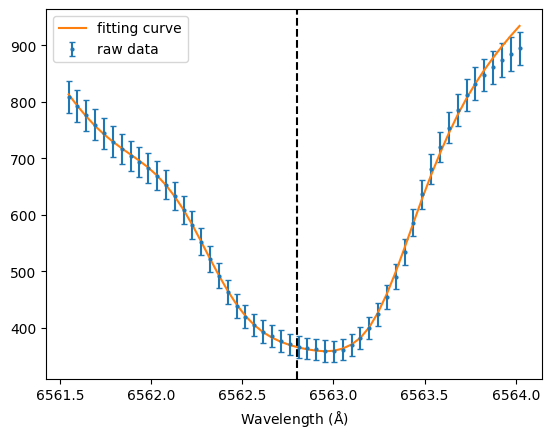

In [20]:
x_opt=np.load('x_opt.npy')
I=spec_data
Icont=I0
fig,ax=plt.subplots()
ax.errorbar(lam,I,yerr=np.sqrt(I),fmt='o',capsize=2,markersize=2,label='raw data')
y_fit = double_cloud_vel(x_opt, vel, Icont)
ax.plot(lam, y_fit, label='fitting curve')
ax.axvline(x=6562.8,linestyle='--',color='black')
ax.set_xlabel('Wavelength $(\mathrm{\AA})$')
ax.legend()

<>:124: SyntaxWarning: invalid escape sequence '\m'
<>:124: SyntaxWarning: invalid escape sequence '\m'
C:\Users\xiao\AppData\Local\Temp\ipykernel_15420\4042083836.py:124: SyntaxWarning: invalid escape sequence '\m'
  ax4.set_xlabel('Wavelength $(\mathrm{\AA})$')


宁静区左下角的位置  y:797.58,x:1540.66
宁静区右上角的位置  y:826.32,x:1569.41
喷流点选取的位置  y:791.00,x:1520.00
喷流选取的位置  y:789.00,x:1515.00
喷流选取的位置  y:806.00,x:1525.00


Text(0.69, 0.05, '$\\mathrm{v_U}$=-15.65 $\\ \\mathrm{km \\ s^{-1}}$\n$\\mathrm{v_L} $= 20.78 $\\ \\mathrm{km \\ s^{-1}}$')

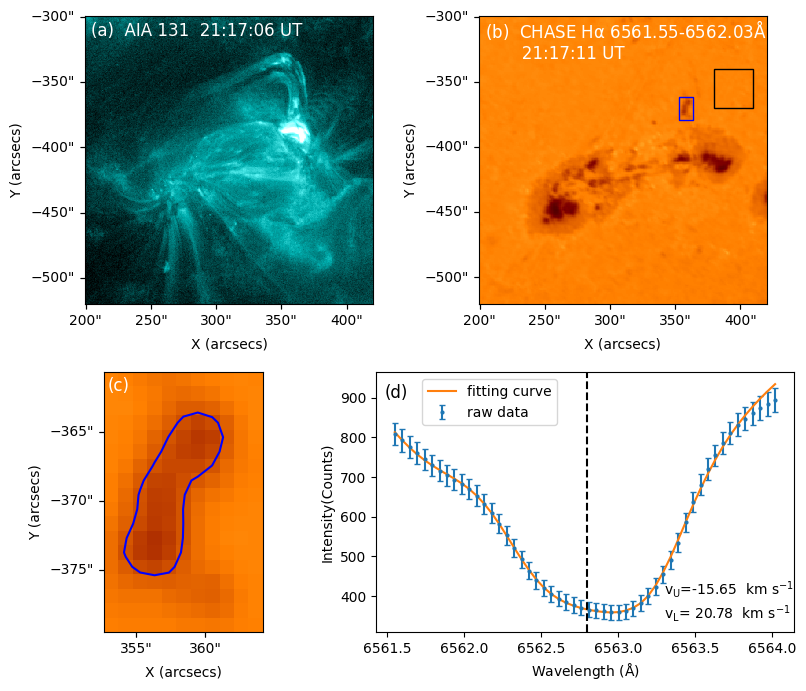

In [ ]:
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)
# 1. wavelength → velocity
lam=lam00[left_index:right_index]#±1.5A
vel = (lam - lam0) / lam0 * c_km  # km/s
#画图
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)

#aia131图像
dir2=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits'
aia=sunpy.map.Map(dir2)
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=aia.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=aia.coordinate_frame)
sub_aia=aia.submap(left_bottom,top_right=top_right)
#----------------------------------------------------------------------------------------------------------------------------
#图1
fig=plt.figure(figsize=(9.5,8))
gs=gridspec.GridSpec(2,1,hspace=0.25,height_ratios=[1,0.9])
gs_top=gridspec.GridSpecFromSubplotSpec(1,2,subplot_spec=gs[0],wspace=0.15,width_ratios=[1,1])
old_norm=sub_aia.plot_settings['norm']
old_norm.vmin=0.01
old_norm.vmax=2000
ax1=fig.add_subplot(gs_top[0],projection=sub_aia)
sub_aia.plot(axes=ax1,norm=old_norm)
#------------------------------------------------------------------------------------------------------------------
#图2
ax2=fig.add_subplot(gs_top[1],projection=sub_hawing_map)
sub_hawing_map.plot(axes=ax2,cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean())

#point1是宁静区左下角
point1=SkyCoord(Tx=380*u.arcsec,Ty=-370*u.arcsec,frame=hawing_map.coordinate_frame)
xpix1,ypix1=hawing_map.world_to_pixel(point1)
print(f'宁静区左下角的位置  y:{ypix1.value:.2f},x:{xpix1.value:.2f}')
#point2是宁静区右上角
point2=SkyCoord(Tx=410*u.arcsec,Ty=-340*u.arcsec,frame=hawing_map.coordinate_frame)
xpix2,ypix2=hawing_map.world_to_pixel(point2)
print(f'宁静区右上角的位置  y:{ypix2.value:.2f},x:{xpix2.value:.2f}')
sub_hawing_map.draw_quadrangle(point1,top_right=point2,axes=ax2,edgecolor='black')

jet_point=(1520,791)
point3=hawing_map.wcs.pixel_to_world(jet_point[0],jet_point[1])
#ax2.plot_coord(point3,marker='o',markersize=3)
xpix3,ypix3=hawing_map.world_to_pixel(point3)
print(f'喷流点选取的位置  y:{ypix3.value:.2f},x:{xpix3.value:.2f}')
#point4是喷流选取左下角
jet_point4=(1515,789)
point4=hawing_map.wcs.pixel_to_world(jet_point4[0],jet_point4[1])
xpix4,ypix4=hawing_map.world_to_pixel(point4)
print(f'喷流选取的位置  y:{ypix4.value:.2f},x:{xpix4.value:.2f}')
#point5是喷流选取右上角
jet_point5=(1525,806)
point5=hawing_map.wcs.pixel_to_world(jet_point5[0],jet_point5[1])
#point5=SkyCoord(Tx=364*u.arcsec,Ty=-363*u.arcsec,frame=hawing_map.coordinate_frame)
xpix5,ypix5=hawing_map.world_to_pixel(point5)
print(f'喷流选取的位置  y:{ypix5.value:.2f},x:{xpix5.value:.2f}')

sub_hawing_map.draw_quadrangle(point4,top_right=point5,axes=ax2,edgecolor='blue')
#----------------------------------------------------------------------------------------------
#图3
gs_down=gridspec.GridSpecFromSubplotSpec(1,2,subplot_spec=gs[1],width_ratios=[0.6,1])
jet_region=sub_hawing_map.submap(point4,top_right=point5)
ax3=fig.add_subplot(gs_down[0],projection=jet_region)
im=jet_region.plot(axes=ax3,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
ax3.coords[0].set_ticks(number=4)

contour=ax3.contour(jet_region.data,levels=[800],colors=['blue'],transform=ax3.get_transform(jet_region.wcs))

#-------------------------------------------------------------------------------------------------
#图4
ax4=fig.add_subplot(gs_down[1])
#获取待拟合光谱
#由contour生成mask
cs = contour
from matplotlib.path import Path
# 初始化 mask
mask = np.zeros_like(jet_region.data, dtype=bool)
# 构造像素坐标网格
ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T  # (N, 2)
# 遍历所有封闭区域
for path in cs.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)
data_jet=rsm[1].data[left_index:right_index,789:807,1515:1526]
data_mask=np.tile(~mask,(right_index-left_index,1,1))
jet_masked=np.ma.array(data_jet,mask=data_mask)
I=jet_masked.mean(axis=(1,2))

#获取拟合参数
x_opt=np.load('x_opt.npy')
ax4.errorbar(lam,I,yerr=np.sqrt(I),fmt='o',capsize=2,markersize=2,label='raw data')
y_fit = double_cloud_vel(x_opt, vel, Icont)
ax4.plot(lam, y_fit, label='fitting curve')
ax4.axvline(x=6562.8,linestyle='--',color='black')
ax4.set_xlabel('Wavelength $(\mathrm{\AA})$')
ax4.set_ylabel('Intensity(Counts)')
ax4.legend(bbox_to_anchor=(0.45, 0.77))

#---------------------------------------------------------------------------------------------------
#画图乱七八糟的部分
ax_all=[ax1,ax2,ax3]
for ax in ax_all:
    #ax.set_xlabel('X (arcsecs)')
    ax.set_xlabel('X (arcsecs)',labelpad=1.2)
    ax.set_ylabel('Y (arcsecs)')
    ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
    ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False) 
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    ax.set_title('')
ax_all[0].text(0.02,0.93,'(a)  AIA 131  21:17:06 UT',color='white',transform=ax_all[0].transAxes,fontsize=12)
ax_all[1].text(0.02,0.85,r'(b)  CHASE H$\mathrm{\alpha}$ 6561.55-6562.03$\mathrm{\AA}$'+'\n       21:17:11 UT',color='white',transform=ax_all[1].transAxes,fontsize=12)
ax_all[2].text(0.02,0.93,'(c)',color='white',transform=ax_all[2].transAxes,fontsize=12)
ax4.text(0.02,0.9,'(d)',color='black',transform=ax4.transAxes,fontsize=12)
ax4.text(0.69,0.05,r'$\mathrm{v_U}$'+'=-15.65 '+r'$\mathrm{km \ s^{-1}}$'+'\n'+r'$\mathrm{v_L} $'+'= 20.78 '+r'$\mathrm{km \ s^{-1}}$',color='black',
         fontsize=10,transform=ax4.transAxes)
#plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig4\double_cloud.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)